# Analyse block trees
In this notebook trees that are created based on blocks (that at least appear 3 times and have a length > 1000) are analysed.

In [ ]:
# set working directory to project folder
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import pandas as pd
import pypangraph as pp

import plotly.io as pio
pio.renderers.default = "browser" 

from pathlib import Path

from junction_analysis.helpers import simplify_cluster_keys
from junction_analysis.junction_trees import cluster_tree_by_branch_length
from junction_analysis.plotting import plot_junction_pangraph_interactive, plot_block_distance_distribution
from junction_analysis.consensus import find_consensus_paths_core
from junction_analysis.block_alignment import summarize_block_msas

### See whether block tree clustering is consistent with core block tree clustering
1. decide on sensible thresholds for core block tree clustering
2. Cluster by trees based on single blocks and see if clustering follows consensus paths

Skipping core: FASTA, alignment and tree already exist in /Users/mariebecker/Documents/Uni/ETH/Masterarbeit/marie-junctions/results/consensus_analysis/RYYAQMEJGY_r__ZTHKZYHPIX_f
Isolate NZ_CP096110.1 filtered out: 30/137 anchor blocks (21.90%)
Isolate NZ_CP103562.1 filtered out: 38/137 anchor blocks (27.74%)
Isolate NZ_CP018953.1 filtered out: 79/136 anchor blocks (58.09%)
Isolate NC_022648.1 filtered out: 58/192 anchor blocks (30.21%)
[{1}, {0, 1}, {1}, {1}, {1}, {1}, {1}, {1}, {0, 1}, {0, 1}, {0, 1}, {0, 1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {0}, {0}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {0}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {0, 1}, {0, 1}, {0, 1}, {0, 1}, {0, 1}, {0, 1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {0, 1}, {1}, {1}, {1}, {1}

/var/folders/l3/cr7pvqjn2054djbp5cf7qbd40000gn/T/ipykernel_37799/2322662236.py:7: UserWarning:

Boolean Series key will be reindexed to match DataFrame index.



,file,block_id,n_seqs,alignment_len,core_len,left_overhang,right_overhang,mismatch_columns,mismatch_fraction,avg_pairwise_dist,avg_consensus_dist,count,n_strains,duplicated,core,len,tree_built
65,block_6362012061147730151_aln.fa,6362012061147730151,196,1085,1075,10,0,0,0.000000,0.000000,0.000000,196,196,False,False,1083,True
133,block_12427157752372396874_aln.fa,12427157752372396874,3,1509,1509,0,0,0,0.000000,0.000000,0.000000,3,3,False,False,1509,True
173,block_17897566196295069196_aln.fa,17897566196295069196,182,1320,1320,0,0,0,0.000000,0.000000,0.000000,182,182,False,False,1320,True
77,block_7166485448600219032_aln.fa,7166485448600219032,145,1786,1779,7,0,1,0.000562,0.000008,0.000004,145,145,False,False,1779,True
61,block_6010508614880330566_aln.fa,6010508614880330566,195,1433,1426,7,0,2,0.001403,0.000014,0.000007,195,195,False,False,1429,True
114,block_10480880799551222441_aln.fa,10480880799551222441,145,1864,1864,0,0,2,0.001073,0.000015,0.000007,145,145,False,False,1864,True
57,block_5598563553016563611_aln.fa,5598563553016563611,140,1623,1623,0,0,20,0.012323,0.000018,0.000009,140,139,True,False,1623,True
141,block_13401516282804455284_aln.fa,13401516282804455284,182,1158,1143,8,7,2,0.001750,0.000019,0.000010,182,182,False,False,1143,True
137,block_12922793938882367282_aln.fa,12922793938882367282,195,1064,1061,0,3,10,0.009425,0.000019,0.000010,195,195,False,False,1060,True
11,block_1448964389002043948_aln.fa,1448964389002043948,145,5385,5385,0,0,22,0.004085,0.000020,0.000010,145,145,False,False,5385,True


/var/folders/l3/cr7pvqjn2054djbp5cf7qbd40000gn/T/ipykernel_37799/2322662236.py:10: UserWarning:

Boolean Series key will be reindexed to match DataFrame index.



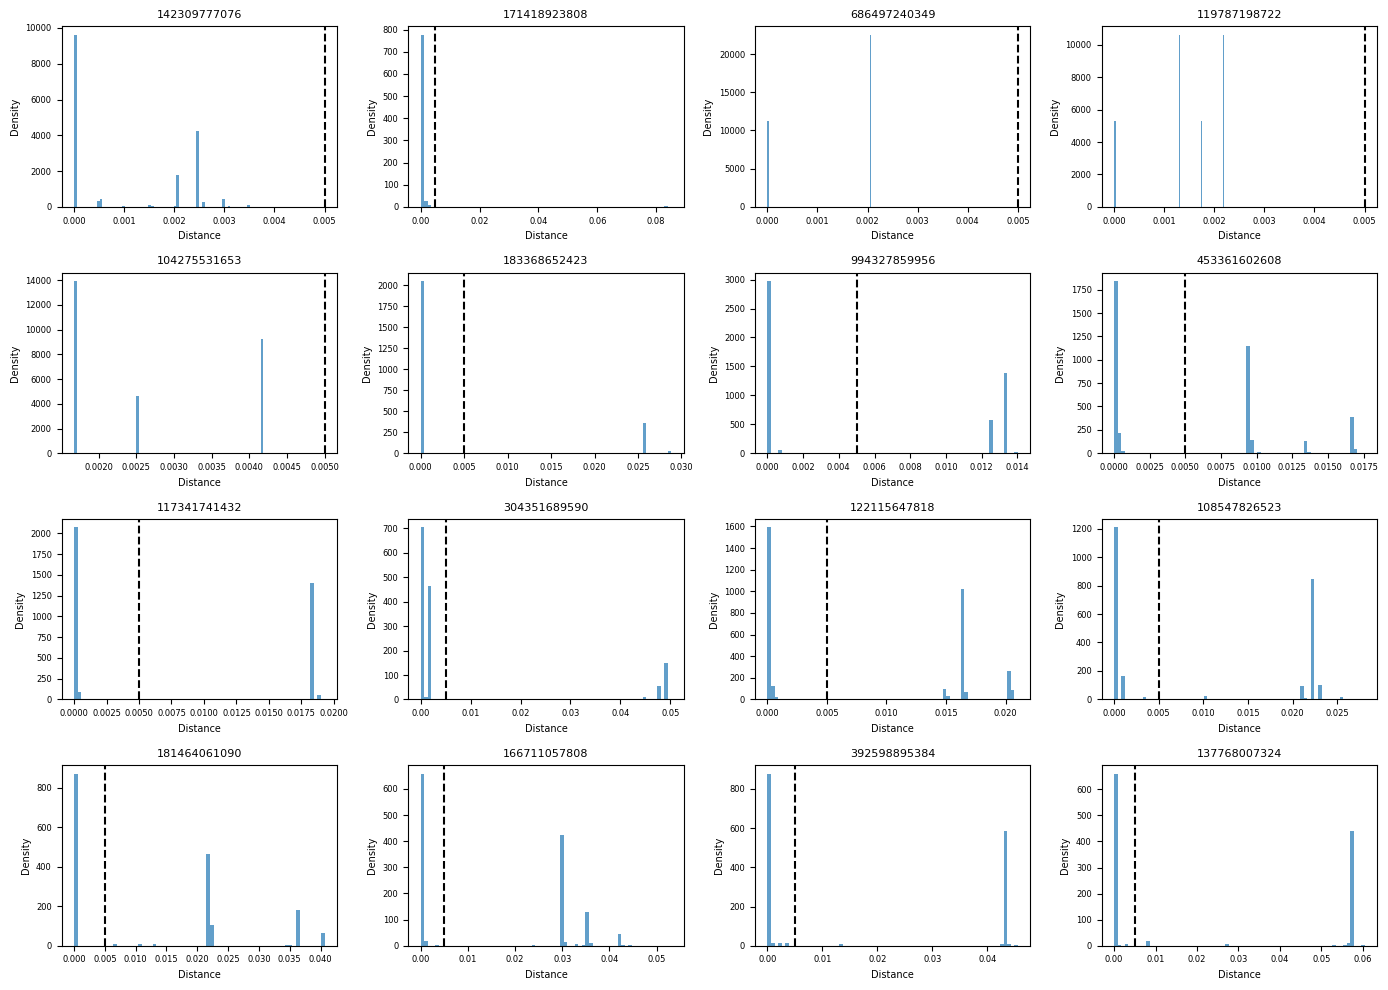

In [ ]:
example_junction = "RYYAQMEJGY_r__ZTHKZYHPIX_f" # junction has 216 isolates
example_pangraph = pp.Pangraph.from_json(f"../results/junction_pangraphs/{example_junction}.json")
cluster_map_core, consensus_paths_core, path_dict, consensus_paths_plotting, assignment_df_plotting, all_root_states, all_root_states_unqiue, ambiguities_df, dedup_stats_df = find_consensus_paths_core(example_junction, plot_consensus=False, plot_pair_dist=False, plot_snp_dist= False, plot_ambiguities=False, clustering_bl_thresh=0.001, consensus_criterium='core_genome_tree', tree_path='../config/polished_tree.nwk')


summary_df = pd.read_csv(f"../results/block_alignments/{example_junction}/{example_junction}_alignment_stats.csv")
display(summary_df.sort_values('avg_pairwise_dist')[summary_df.tree_built == True])

_, pair_dists = summarize_block_msas(example_junction, save_df=False, return_pairwise_dists=True)
block_ids = summary_df.sort_values('avg_pairwise_dist')[(summary_df.tree_built == True) & (summary_df.avg_pairwise_dist > 0.001)].block_id

plot_block_distance_distribution(
    pair_dists,
    block_ids,
    bins=70,
    cols=4,
    figsize=(14, 10),
    vline=0.005,                     # draw a vertical line at distance 0.05
    vline_kwargs={"color": "black", "linestyle": "--"}
)


In [3]:
block_id = 1377680073246787056 # block with highest diversity that is long enough and has enough sequences
#block_id = 3925988953842971952 # block with second highest diversity that is long enough and has enough sequences
#block_id = 8046715219054472333 # highest diversity block shared only by consensus_6, consensus_7 blocks
#block_id = 16671105780806995519	# first core block, also block with highest diversity that is present in all isolates --> gives very good clustering that fits desired consensus paths
#block_id = 18146406109094649449 # second core block


In [ ]:
def visualize_block_clustering(pangraph, junction_name, consensus_paths, assignment_df, block_id, dist_threshold=0.005):

    tree_path = Path(f"../results/block_alignments/{junction_name}/block_{block_id}_aln.tree")

    cluster_map = cluster_tree_by_branch_length(tree_path, dist_threshold)
    cluster_map = simplify_cluster_keys(cluster_map)

    fig = plot_junction_pangraph_interactive(
        pangraph,
        show_consensus=True,
        consensus_paths=consensus_paths,
        assignments=assignment_df,
        order="tree",
        cluster_map=cluster_map,
        title = f"Junction Block Structure with block {block_id} Tree Clustering"
    )
    display(fig)

    return cluster_map

In [5]:
# block with highest diversity that is long enough and has enough sequences (blue block in the second half)
cluster_map = visualize_block_clustering(example_pangraph, example_junction, consensus_paths_plotting, assignment_df_plotting, block_id = 1377680073246787056, dist_threshold=0.005)
# clustering is consistent with consensus path clustering, two sequences are retrieved as a subcluster of consensus_1

# second highest diversity, light blue block in the first half
cluster_map = visualize_block_clustering(example_pangraph, example_junction, consensus_paths_plotting, assignment_df_plotting, block_id = 3925988953842971952, dist_threshold=0.005)
# clustering matches consensus path clustering for the consensus paths where block is present

# only present in consensus_5, red block in the middle
cluster_map = visualize_block_clustering(example_pangraph, example_junction, consensus_paths_plotting, assignment_df_plotting, block_id = 8046715219054472333, dist_threshold=0.005)
# all sequences cluster together as expected

In [ ]:
for bid in block_ids:
    cluster_map = visualize_block_clustering(example_pangraph, example_junction, consensus_paths_plotting, assignment_df_plotting, block_id = bid, dist_threshold=0.005)

# 7 min

Results:
- most blocks fit the clustering of the core blocks
- some blocks suggest sub-clustering of some of the consensus baths (usually individual (1 or 2) isolates that differ), still consistent with core block clustering
- for some blocks suggest that several consensus paths should be the same cluster, e.g. 3043516895904981143 (also around 1000bp)
- 10854782652321820035 shows a little bit of intermixing between clusters, relativly short (around 1000bp, light blue)

Further analysis:
- Compare the clusterings between different blocks. To do that look at all pairs of two isolates and compare whether they are in the same cluster or in different clusters. Then calculate a score how many of the isolates that are in the same cluster are also in the same cluster on a different block and how many aren't. Also calculate a score how many of the isolates that are in different clusters are also in different clusters on a different block. For now just use isolate names and ignore duplicate blocks.